<a href="https://colab.research.google.com/github/praveenkumarreddyaturu104/TENSORFLOW/blob/main/colab02_2_Neural_network___classifiction___tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##working with a large example
* it means if we have 3- 9999... different class it is multiclass classification problem




* for practice multi-class classification ,we are going to built a neural network to classify images of different type of clothing(https://www.tensorflow.org/datasets/catalog/fashion_mnist)

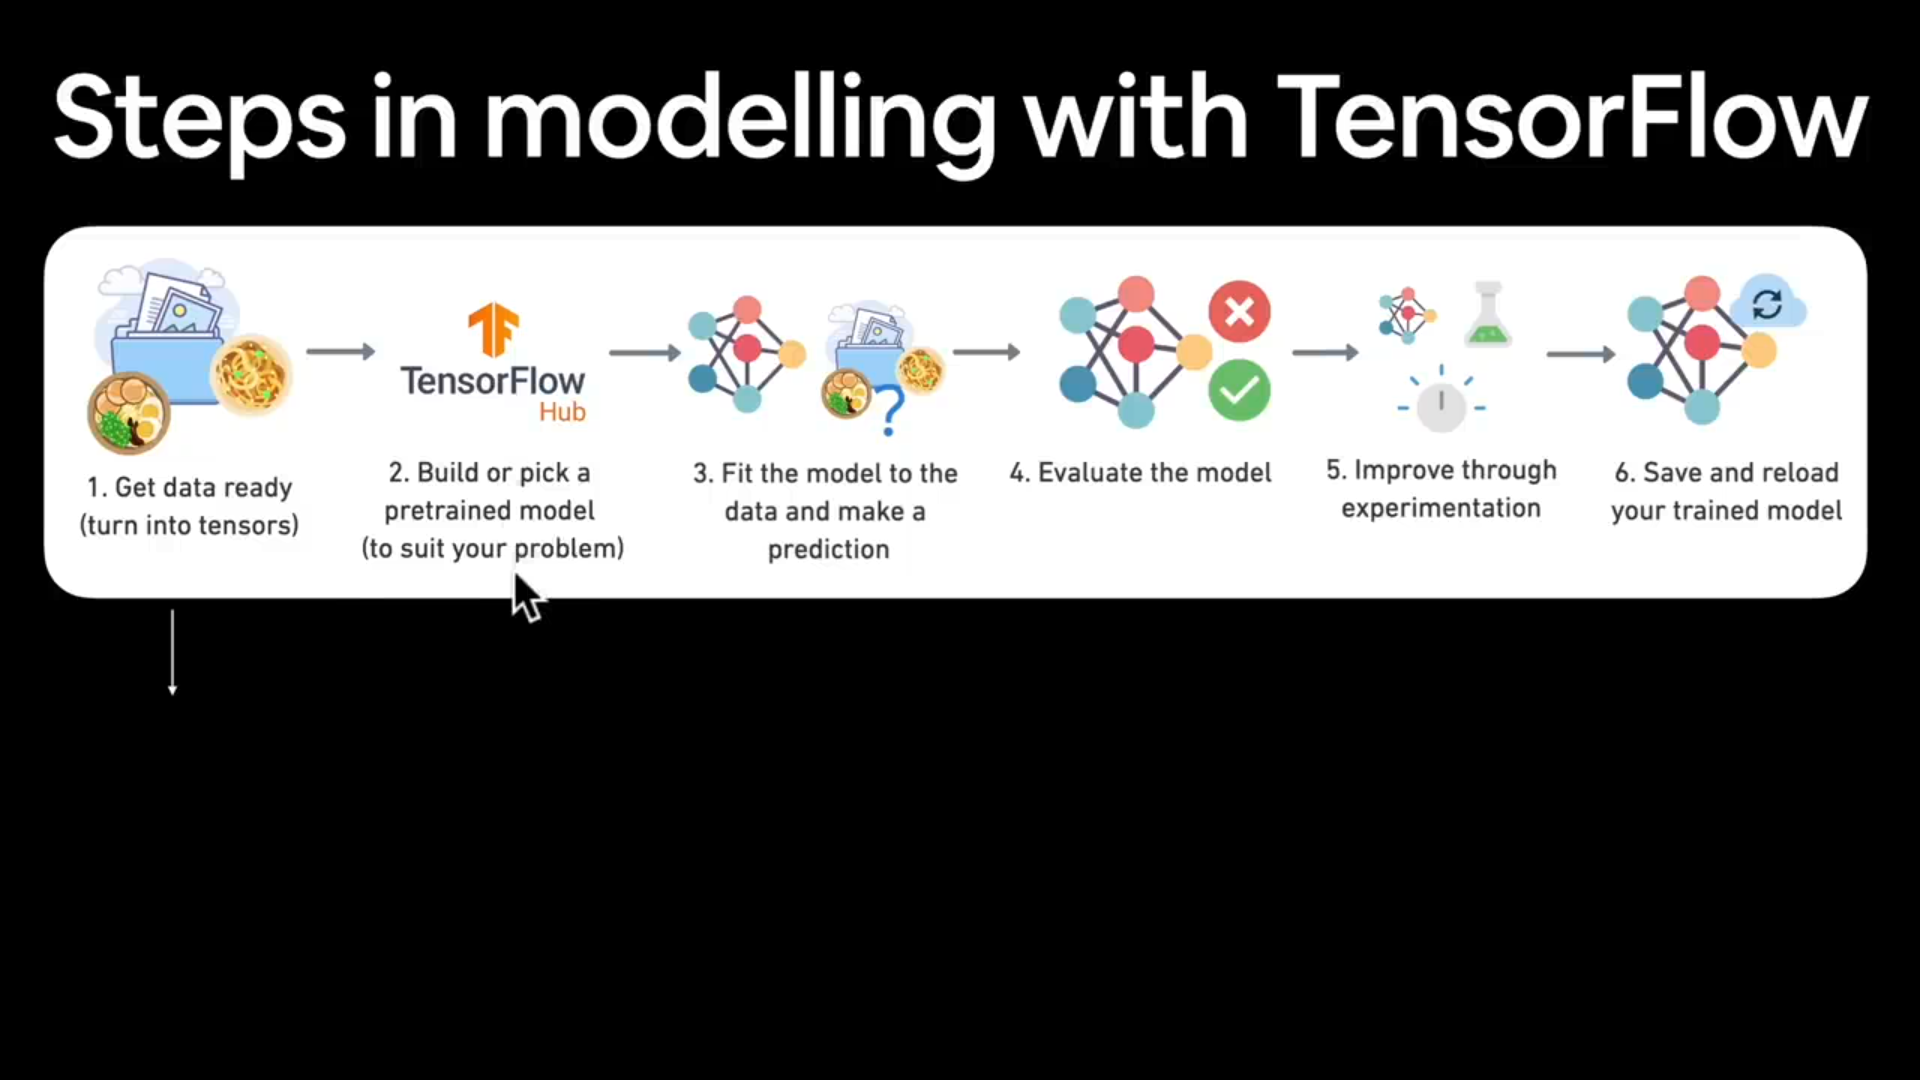

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
#the data has already been sorted into training and test sets for us
(train_data,train_labels),(test_data,test_labels)=fashion_mnist.load_data()=

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
#show the first training example
print(f"training sample:\n{train_data[0]}\n")
print(f"training labels:\n{train_labels[0]}\n")

training sample:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1  

In [3]:
#check the shape of the single example
train_data[0].shape,train_labels[0].shape

((28, 28), ())

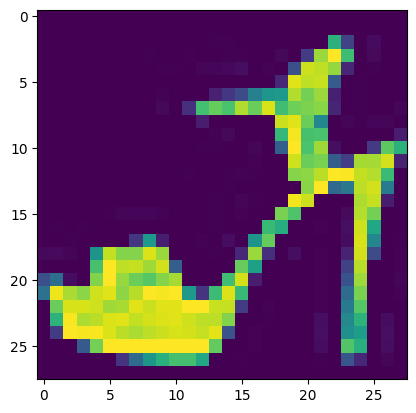

In [4]:
#plot the single sample
import matplotlib.pyplot as plt
plt.imshow(train_data[9])

In [5]:
#create a smale list so we can index into our training labels so they are human readable
class_name=["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
len(class_name)

10

Text(0.5, 1.0, 'Sandal')

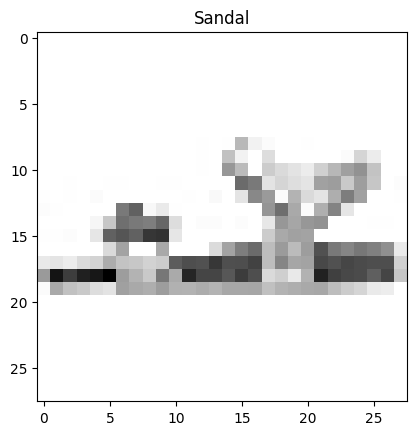

In [6]:
#plot an example image and its label
index_of_choice=59999
plt.imshow(train_data[index_of_choice], cmap=plt.cm.binary)
plt.title(class_name[train_labels[index_of_choice]])

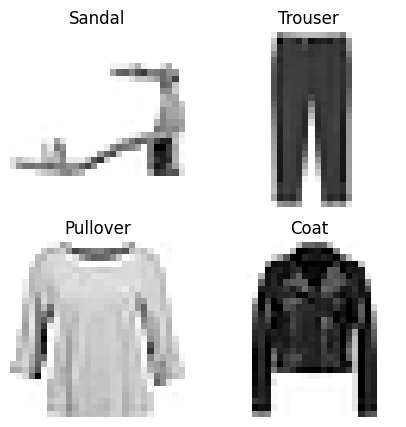

In [7]:
#plot multiple random impages of  fashion mnist
import random
plt.figure(figsize=(5,5))
for i in range(4):
  ax=plt.subplot(2,2,i+1)
  rand_index=random.choice(range(len(train_data)))
  plt.imshow(train_data[rand_index],cmap=plt.cm.binary)
  plt.title(class_name[train_labels[rand_index]])
  plt.axis(False)

#buitlding a multiclass classifcation model

for our multi-class classification model,we can use similar architecture of binary classification
# different things are
* input shape= 28X28
* output shape=10
* loss function=keras.losses.CategoricalCrossentropy()
* output activation function softmax

In [8]:
#set random seed
tf.random.set_seed(42)

#create model
model_5=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(100,activation="relu"),
    tf.keras.layers.Dense(80,activation="relu"),
    tf.keras.layers.Dense(50,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

#compile the model
model_5.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
#non normalized data fitting
norm_h = model_5.fit(train_data,
                     train_labels,
                     epochs=10,
                     validation_data=(test_data,test_labels)
                     )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.7491 - loss: 1.3088 - val_accuracy: 0.7625 - val_loss: 0.6568
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.8192 - loss: 0.5129 - val_accuracy: 0.8202 - val_loss: 0.5185
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8353 - loss: 0.4612 - val_accuracy: 0.8415 - val_loss: 0.4603
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8474 - loss: 0.4241 - val_accuracy: 0.8380 - val_loss: 0.4462
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8559 - loss: 0.4020 - val_accuracy: 0.8386 - val_loss: 0.4626
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8628 - loss: 0.3815 - val_accuracy: 0.8445 - val_loss: 0.4385
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8679 - loss: 0.3677 - val_accuracy: 0.8331 - val_loss: 0.4695
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8720 - loss: 

In [9]:
#check the model
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         4,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273,422 (1.04 MB)

 Trainable params: 91,140 (356.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 182,282 (712.04 KB)

In [10]:
#check the min and max values of the training data
train_data.min(),train_data.max()

(np.uint8(0), np.uint8(255))

Neural newtworks prefer datad to be sclaed (or normalized) this means they like to have the number in 0 & 1

In [11]:
#we can get our training and testing data between 0 & 1 by dividing by the maximum
train_data_norm=train_data/255.0
test_data_norm=test_data/255.0

#check the min and max values of the scaled training data
train_data_norm.min(),train_data_norm.max()

(np.float64(0.0), np.float64(1.0))

In [12]:
#now our data is normalized
#set random seed
tf.random.set_seed(42)

#create a model
model_6=tf.keras.Sequential([
    tf.keras.Input(shape=(28,28)), # Recommended way to specify input shape
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100,activation="relu"),
    tf.keras.layers.Dense(80,activation="relu"),
    tf.keras.layers.Dense(50,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

#mode_6 compiling
model_6.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

#model_6 fitting
horm_hist=model_6.fit(train_data_norm,
                      train_labels,
                      epochs=10,
                      validation_data=(test_data_norm, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8197 - loss: 0.5020 - val_accuracy: 0.8423 - val_loss: 0.4330
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.8655 - loss: 0.3687 - val_accuracy: 0.8567 - val_loss: 0.3849
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8764 - loss: 0.3328 - val_accuracy: 0.8662 - val_loss: 0.3701
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8842 - loss: 0.3088 - val_accuracy: 0.8704 - val_loss: 0.3661
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.8916 - loss: 0.2894 - val_accuracy: 0.8742 - val_loss: 0.3549
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8951 - loss: 0.2771 - val_accuracy: 0.8738 - val_loss: 0.3537
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.9003 - loss: 0.2645 - val_accuracy: 0.8727 - val_loss: 0.3562
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9040 - loss:

<Axes: title={'center': 'normalized data'}>

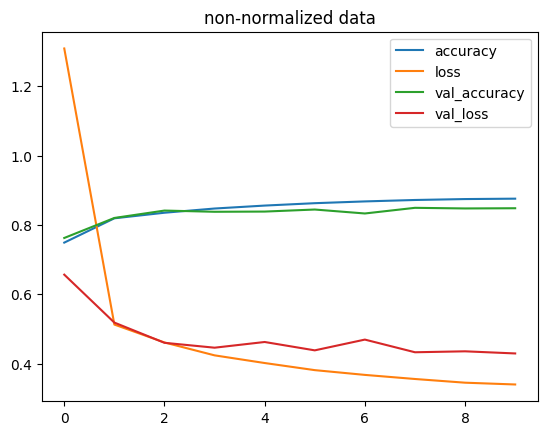

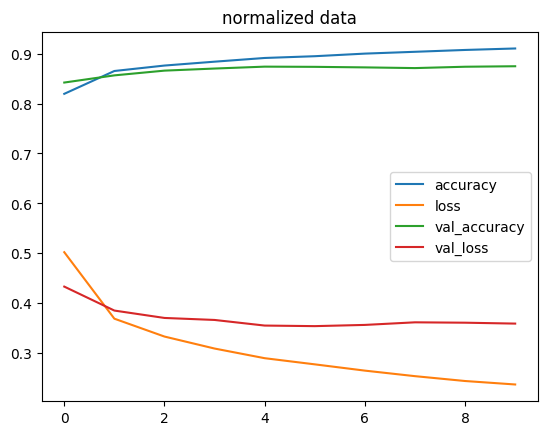

In [13]:
import pandas as pd
#plot non_normalize data loss curve
pd.DataFrame(norm_h.history).plot(title="non-normalized data")
#plot normalized data loss curve
pd.DataFrame(horm_hist.history).plot(title="normalized data")

In [14]:
##finding the ideal learning rate
#set random seed
tf.random.set_seed(42)

#creating model_7
lr_model_7=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

#compiling model_7
model_7.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

#creating callback to fit model
lr_s=tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3*10**(epoch/20))


#mode_7 fitting
lr_h=model_7.fit(train_data_norm,train_labels,epochs=40,validation_data=(test_data_norm,test_labels),callbacks=[lr_s])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5253 - loss: 1.2673 - val_accuracy: 0.6394 - val_loss: 0.9281 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7014 - loss: 0.8009 - val_accuracy: 0.7579 - val_loss: 0.6951 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7754 - loss: 0.6363 - val_accuracy: 0.7727 - val_loss: 0.6297 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7854 - loss: 0.5968 - val_accuracy: 0.7817 - val_loss: 0.6092 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7901 - loss: 0.5804 - val_accuracy: 0.7878 - val_loss: 0.5984 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7938 - loss: 0.5709 - val_accuracy: 0.7902 - val_loss: 0.5996 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.795

Text(0.5, 1.0, 'finding ideal lr')

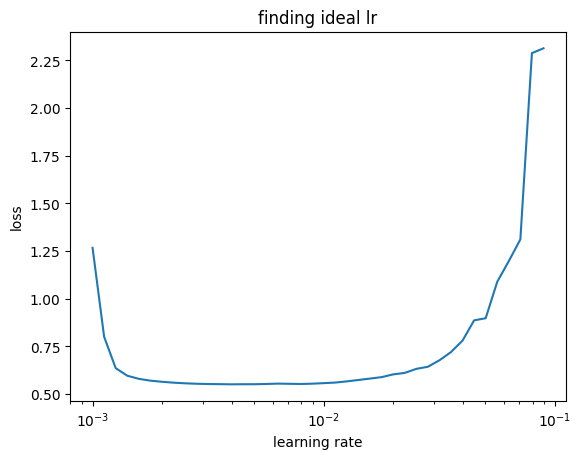

In [15]:
#plot learning rate decay curve
import numpy as np
import matplotlib.pyplot as plt

lsr = 1e-3*(10**(tf.range(40)/20))
plt.semilogx(lsr,lr_h.history["loss"])
plt.xlabel("learning rate")
plt.ylabel("loss")
plt.title("finding ideal lr")

In [16]:
#creating confusion matirx


In [124]:
import itertools
from sklearn.metrics import confusion_matrix

figsize=(10,10)
def make_confusion_matrix(y_true,y_pred,classes=None,figsize=(10,10),text_size=15):
  #create the confusion matrix
  cm=confusion_matrix(y_true,y_pred)
  cm_norm=cm.astype("float")/cm.sum(axis=1)[:,np.newaxis]#normilize our confusion matrix
  n_classes=cm.shape[0]

  fig,ax=plt.subplots(figsize=figsize)
  #create a matrix plot
  cax=ax.matshow(cm,cmap=plt.cm.Blues)
  fig.colorbar(cax)
  plt.scale("Flase")
  if classes:
    labels=classes
  else:
    labels=np.arange(cm.shape[0])

  #lables the axes
  ax.set(title="Confusion Matrix",
        xlabel="Predicted Label",
        ylabel="true label",
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes),
        xticklabels=labels,
        yticklabels=labels)

  #set X-axis labels to bottem
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()
  #adjust labels size
  ax.yaxis.label.set_size(text_size)
  ax.xaxis.label.set_size(text_size)
  ax.title.set_size(text_size)
  #set threshold for different color  s
  threshold=(cm.max()+cm.min())/2

  #plot the text on each cell
  for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
    plt.text(j,i,f"{cm[i,j]}({cm_norm[i,j]*100:1f}%)", horizontalalignment="center",
            color="orange" if cm[i,j]>threshold else "black",
            size=text_size
            )

In [18]:
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [28]:
#make some predictions
y_probs=model_6.predict(test_data_norm)#probs is short of "prediction probability"

#view the first 5 predictions
y_probs[0],
tf.argmax(y_probs[0]),
class_name[tf.argmax(y_probs[0])]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


'Ankle boot'

In [29]:
#convert all of the prediction probalilites into integers
y_preds=y_probs.argmax(axis=1)

#view the first 10 prediction labels
y_preds[:10]


array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [21]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true=test_labels,
                 y_pred=y_preds)

array([[821,   2,  20,  27,   5,   2, 119,   0,   4,   0],
       [  1, 968,   3,  21,   3,   0,   3,   0,   1,   0],
       [ 16,   1, 794,  21, 124,   0,  44,   0,   0,   0],
       [ 15,   4,   9, 906,  32,   1,  29,   1,   3,   0],
       [  1,   0, 101,  42, 831,   0,  24,   0,   1,   0],
       [  0,   0,   0,   1,   0, 938,   0,  35,   0,  26],
       [124,   2, 112,  37, 105,   0, 613,   0,   7,   0],
       [  0,   0,   0,   0,   0,   8,   0, 977,   0,  15],
       [  8,   0,   4,   6,   4,   5,   3,   5, 965,   0],
       [  0,   0,   0,   0,   0,   2,   1,  60,   0, 937]])

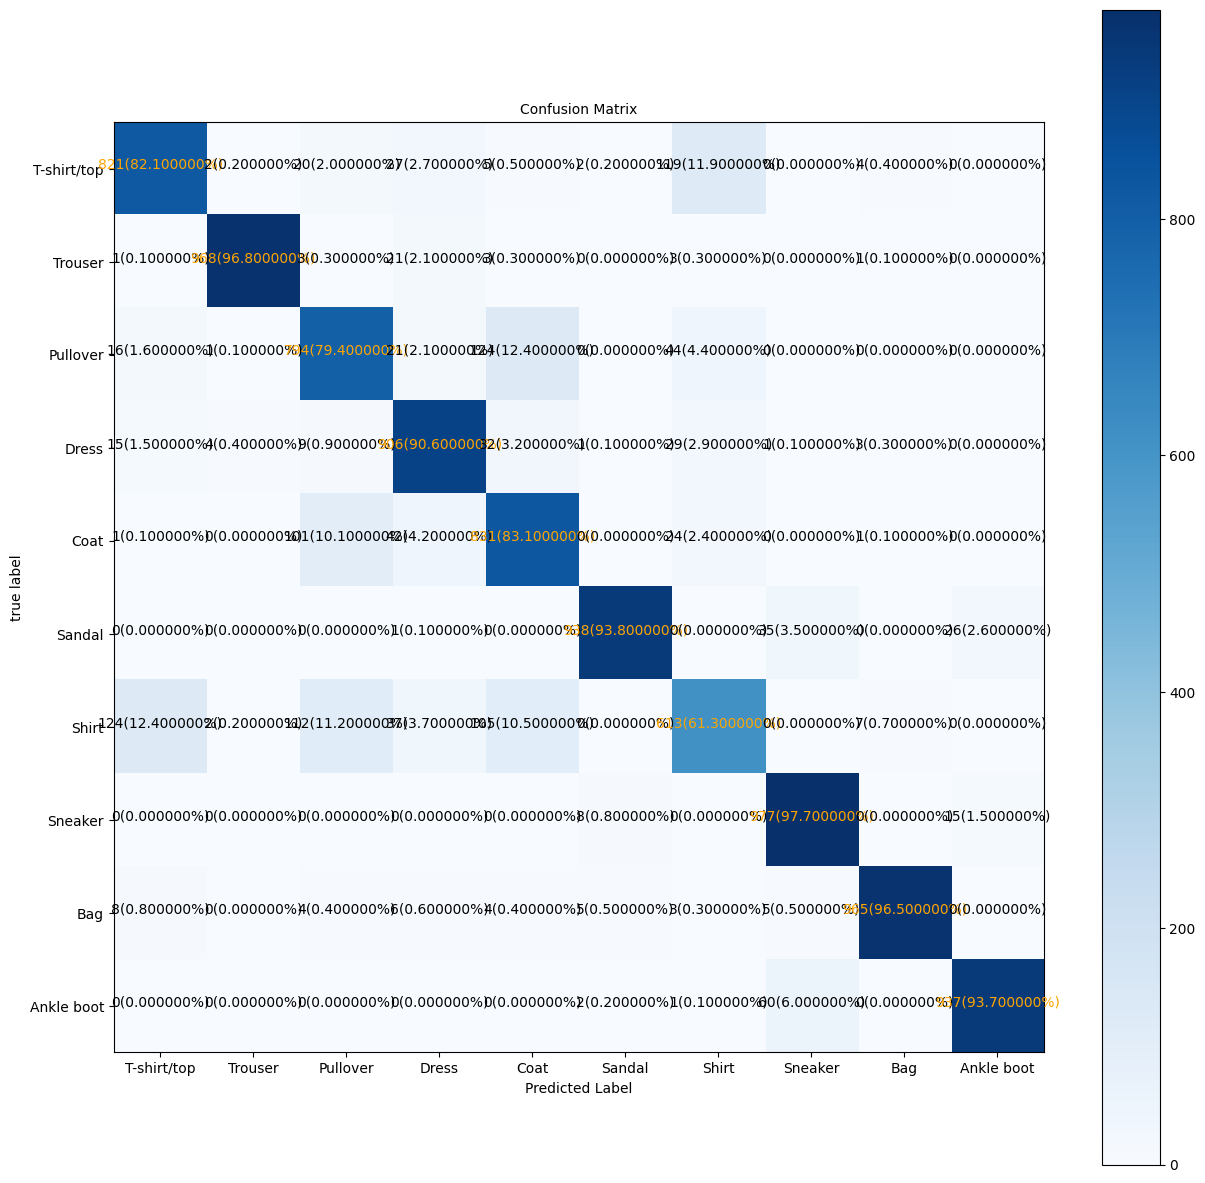

In [22]:
#creating confusion matrix
make_confusion_matrix(y_true=test_labels,
                      y_pred=y_preds,
                      classes=class_name,
                      figsize=(15,15),
                      text_size=10)

In [133]:
import random

def plot_image(model,image,true_labels,classes):
  """
  picks a random image ,plots it and lables it with a predicion and truth labels
  """
  #set up random integer
  i=random.randint(0,len(image))


  #create prediction and target
  target_image=image[i]
  pred_probs=model.predict(target_image.reshape(1,28,28))
  pred_label=classes[pred_probs.argmax()]
  true_label=classes[true_labels[i]]

  #plot image
  plt.imshow(target_image,cmap=plt.cm.binary)

  #change the color of the titlr depending on if the prediction is right or wrong
  if pred_label==true_label:
    color="green"
  else:
    color="red"
  #add xlabel information (prediction/true label)
  plt.xlabel("perd: {}{:2.0f}% true:{}".format(pred_label,
                                                 100*tf.reduce_max(pred_probs),
                                                 true_label),
             color=color)#setting color depending on red,green

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


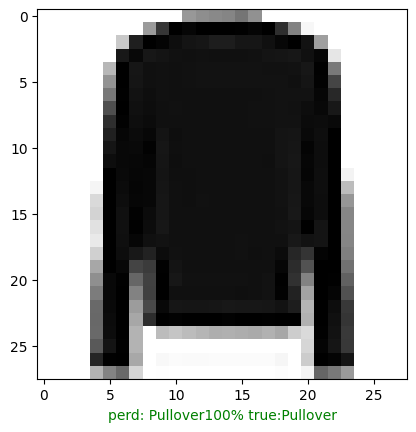

In [134]:
#check out a ranom image as well as its prediction
plot_image(model=model_6,image=test_data,true_labels=test_labels,
                  classes=class_name)

learning patterns in our model

In [116]:
#find the layers of most recent model
model_6.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>,
 <Dense name=dense_6, built=True>,
 <Dense name=dense_7, built=True>]

In [118]:
#extract particular layers
model_6.layers[2]

<Dense name=dense_5, built=True>

In [120]:
#get the pattern of a layer in our network
weights,bias=model_6.layers[1].get_weights()

#shapes
weights,weights.shape

(array([[-0.08120576,  0.01330022,  0.09395707, ...,  0.05214742,
         -0.280263  ,  0.03009869],
        [-0.03378511, -0.12149744, -0.21843104, ..., -0.00433274,
          0.36009976,  0.01528377],
        [-0.00766469, -0.04208111, -0.5086841 , ..., -0.04239269,
          0.15400635,  0.0194064 ],
        ...,
        [-0.01311331,  0.15289874, -0.3062541 , ..., -0.38181615,
          0.4759322 , -0.03833297],
        [-0.06375882,  0.29614404,  0.13911238, ...,  0.16066998,
          0.31592605, -0.00214532],
        [-0.02409343,  0.46011788, -0.15075262, ..., -0.00973198,
          0.3436294 ,  0.00973724]], dtype=float32),
 (784, 100))

In [121]:
model_6.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         4,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273,422 (1.04 MB)

 Trainable params: 91,140 (356.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 182,282 (712.04 KB)

In [137]:
#now lets check bias,bias shape
bias,bias.shape

(array([-0.02259479,  0.04177466, -0.38876   , -0.02809891,  0.17568871,
         0.23999155,  0.22460221, -0.04217484,  0.32957384,  0.14581485,
         0.0480963 , -0.12748507,  0.40190846,  0.52448285,  0.22696345,
        -0.11223603, -0.12173323, -0.18772098,  0.25528854,  0.08365265,
         0.12499738,  0.22907159,  0.36060607, -0.05707132,  0.12913436,
         0.09407538,  0.25694007, -0.01657361, -0.0019389 , -0.4492508 ,
         0.2923703 , -0.01698818,  0.01898559,  0.2818643 , -0.01425358,
         0.53951174,  0.07983892,  0.19811462,  0.56502646,  0.14610824,
         0.31027684, -0.51815104,  0.1791497 ,  0.14133064,  0.16070117,
         0.30463934,  0.26996464,  0.0793237 ,  0.30208176,  0.19133145,
         0.30139887,  0.5324847 , -0.0322247 ,  0.08394293,  0.64797956,
         0.09744046,  0.18446252, -0.5593478 ,  0.10036843, -0.30735183,
         0.18730539,  0.42021722, -0.11012816,  0.2114671 ,  0.05828237,
        -0.33227473, -0.03025468,  0.4005358 ,  0.1

every neuron has a bias vector.each of these is paired with a weights matrix.

the bias vector get initialized  as zeros.

the bias vector dictacts how much the pattern with in the pattern within the corresponding weigths matrix should influence the next layer.

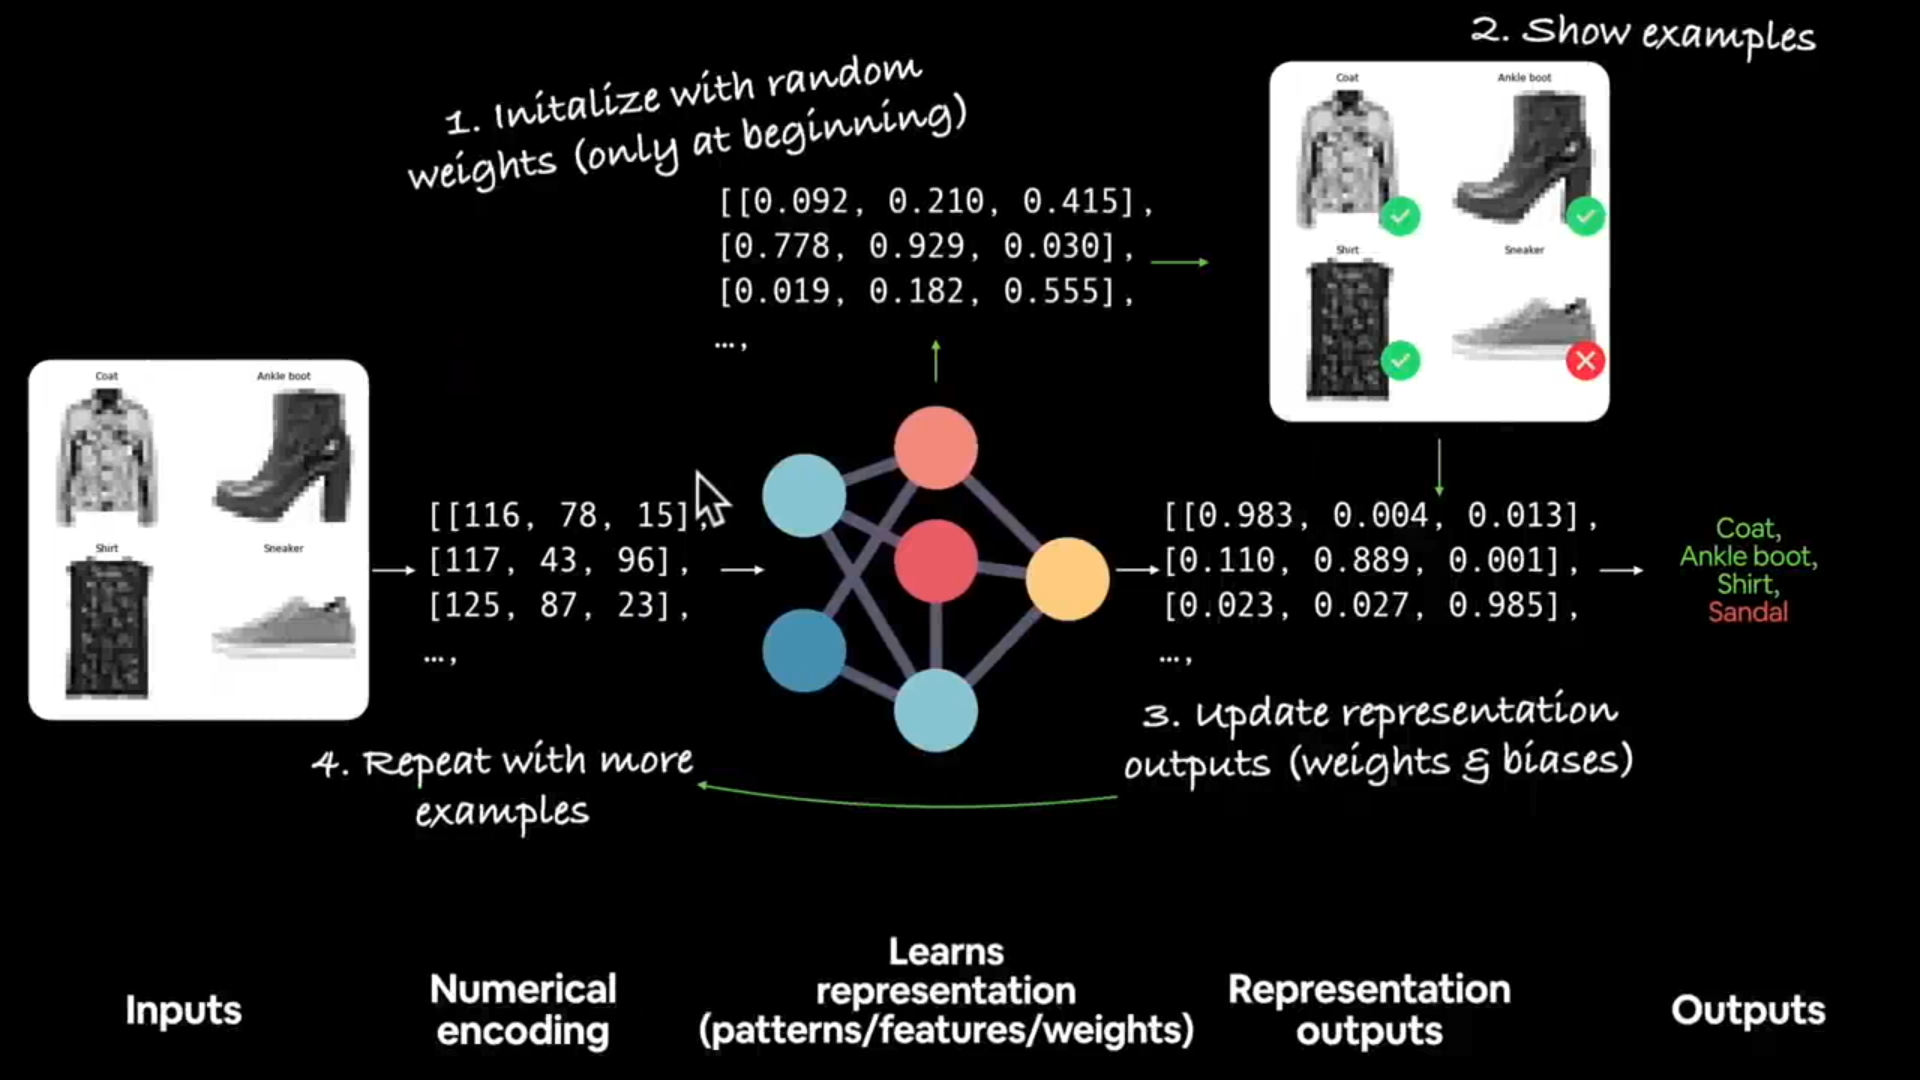

In [138]:
model_6.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         4,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273,422 (1.04 MB)

 Trainable params: 91,140 (356.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 182,282 (712.04 KB)

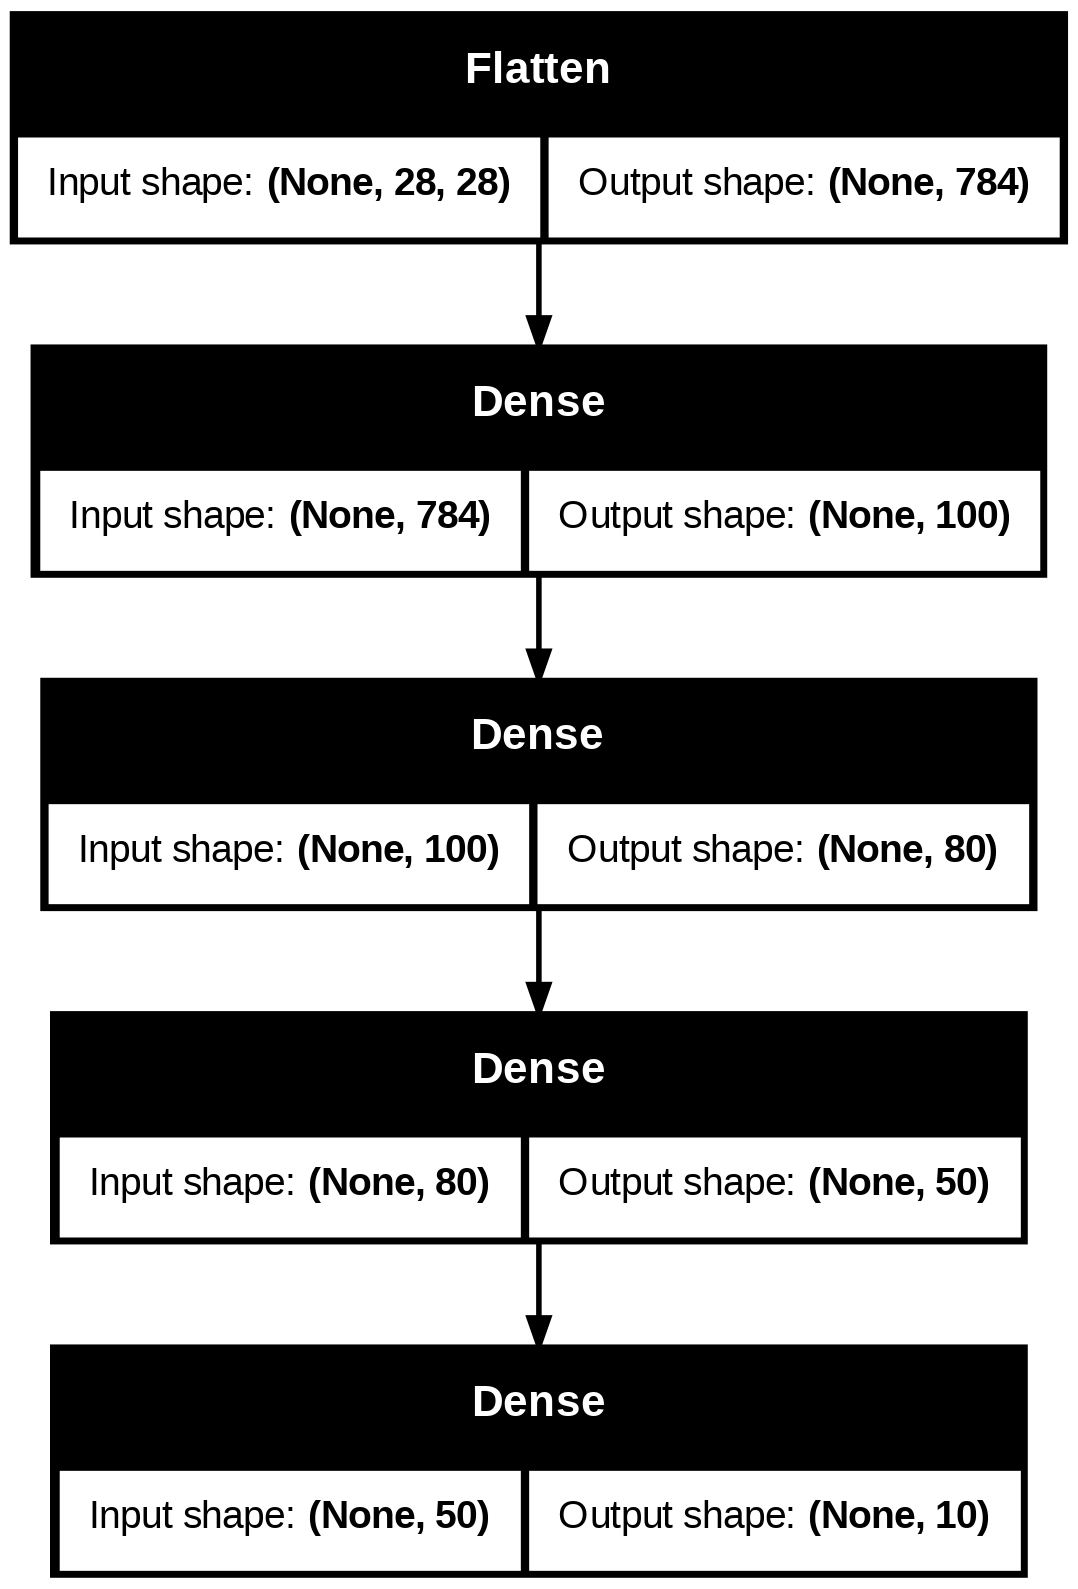

In [139]:
#let's check out another way of viewing our deep learning models
from tensorflow.keras.utils import plot_model
#see the inout and output of each layer
plot_model(model_6,show_shapes="True")